# Backtest 2025/26: Model 1 vs Model 2

Porównanie obu modeli drużynowych na tym samym splitcie co `02_model1_static_team` i `03_model2_hierarchical_team`:

- trening: sezony `0910`–`2425`
- test: sezon `2526`

Dla każdej drużyny: predykcja punktów (`predict_team_points`) → tabela (`build_predicted_table`) → błędy vs rzeczywistość.

**Skill w prognozie:** Model 1 — stały `beta_pts * skill[team]`. Model 2 — `team_skill[team]` z posterioru + świeży wspólny `season_effect` dla sezonu testowego; indywidualna jednoroczna niepewność jest w predykcyjnym Student-t residual noise.

Metryki sezonu: suma \|błędu\| oraz średnia na drużynę = `sum |error| / n_teams`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_static,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    build_predicted_table,
    compare_forecast_to_actual,
    forecast_season_summary,
    forecast_team_errors,
    print_forecast_season_summary,
    plot_forecast_team_errors,
    summarize_models,
    compare_models_team_errors,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)

matches = load_matches()
TRAIN = BACKTEST_TRAIN_SEASONS
TEST = BACKTEST_TEST_SEASON
FEATURE_SEASON = TRAIN[-1]
test_teams = sorted(teams_in_season(matches, TEST))
print(f"Test season {TEST}: {len(test_teams)} teams")


Test season 2526: 20 teams


In [2]:
tables = load_season_tables(matches, TRAIN)

stan_static, team_to_idx_s, _, feature_stats = prepare_table_stan_static(tables, TRAIN)
stan_static["nu"] = STUDENT_T_NU
forecast_features = build_forecast_features(
    matches, FEATURE_SEASON, test_teams, TRAIN, feature_stats
)

stan_hier, team_to_idx_h, _, _, _ = prepare_table_stan_hierarchical(tables, TRAIN)
stan_hier["nu"] = STUDENT_T_NU

sample_kwargs = dict(
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=800,
    iter_sampling=800,
    adapt_delta=0.99,
    show_progress=True,
)

fit_static = CmdStanModel(stan_file="stan/team_static.stan").sample(data=stan_static, **sample_kwargs)
fit_hier = CmdStanModel(stan_file="stan/team_hierarchical.stan").sample(data=stan_hier, **sample_kwargs)


12:15:34 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

12:15:40 - cmdstanpy - INFO - CmdStan done processing.


## Predykcje i błędy — oba modele


In [3]:
pred_static = build_predicted_table(
    fit_static, test_teams, team_to_idx_s,
    model="static", team_features=forecast_features, n_sims=500, seed=42,
)
pred_hier = build_predicted_table(
    fit_hier, test_teams, team_to_idx_h,
    model="hierarchical", team_features=forecast_features, n_sims=500, seed=43,
)

cmp_static = compare_forecast_to_actual(pred_static, matches, TEST)
cmp_hier = compare_forecast_to_actual(pred_hier, matches, TEST)

overall = summarize_models({
    "Model 1 (static)": cmp_static,
    "Model 2 (hierarchical)": cmp_hier,
})

print("=== Podsumowanie całej tabeli (sezon testowy) ===")
display(overall)

for label, cmp in [("Model 1 (static)", cmp_static), ("Model 2 (hierarchical)", cmp_hier)]:
    print()
    print_forecast_season_summary(forecast_season_summary(cmp), season=TEST, title=label)

team_both = compare_models_team_errors(
    cmp_static, cmp_hier, label_a="static", label_b="hierarchical"
)
print("\n=== Błąd punktów per drużyna — porównanie modeli ===")
display(team_both)


=== Podsumowanie całej tabeli (sezon testowy) ===


,Model 1 (static),Model 2 (hierarchical)
n_teams,20.000000,20.000000
pts_pred_mean,53.554198,53.506546
pts_actual_mean,51.800000,51.800000
pts_mae,9.194581,8.770829
pts_abs_error_sum,183.891615,175.416589
pts_bias,1.754198,1.706546
pos_mae,3.800000,3.500000
pos_abs_error_sum,76.000000,70.000000
pos_bias,0.000000,0.000000



Season 2526 — Model 1 (static)
  Sum |point error| over all teams:  184 pts
  Mean |point error| per team:        9.19 pts  (184 / 20)
  Mean signed point error (bias):     +1.75 pts
  Mean predicted / actual points:     53.6 / 51.8
  Sum |position error|:               76 places
  Mean |position error| per team:     3.80 places  (76 / 20)

Season 2526 — Model 2 (hierarchical)
  Sum |point error| over all teams:  175 pts
  Mean |point error| per team:        8.77 pts  (175 / 20)
  Mean signed point error (bias):     +1.71 pts
  Mean predicted / actual points:     53.5 / 51.8
  Sum |position error|:               70 places
  Mean |position error| per team:     3.50 places  (70 / 20)

=== Błąd punktów per drużyna — porównanie modeli ===


,team,pts_error_static,pts_abs_error_static,pos_abs_error_static,pts_error_hierarchical,pts_abs_error_hierarchical,pos_abs_error_hierarchical,pts_abs_error_diff_static_minus_hierarchical
19,Wolves,28.076256,28.076256,4,27.022089,27.022089,4,1.054166
16,Sunderland,-18.431906,18.431906,12,-18.094229,18.094229,12,0.337676
17,Tottenham,16.948450,16.948450,11,16.857581,16.857581,11,0.090869
6,Chelsea,15.673113,15.673113,6,15.118060,15.118060,6,0.555052
0,Arsenal,-14.786222,14.786222,1,-14.625477,14.625477,1,0.160745
5,Burnley,13.536819,13.536819,1,13.687021,13.687021,1,-0.150203
1,Aston Villa,-11.421860,11.421860,5,-10.473052,10.473052,3,0.948808
10,Leeds,-11.025611,11.025611,4,-11.076862,11.076862,4,-0.051251
11,Liverpool,10.149893,10.149893,2,9.143229,9.143229,2,1.006664
13,Man United,-7.681032,7.681032,2,-6.294622,6.294622,2,1.386411


## Wykresy błędów i pred vs actual


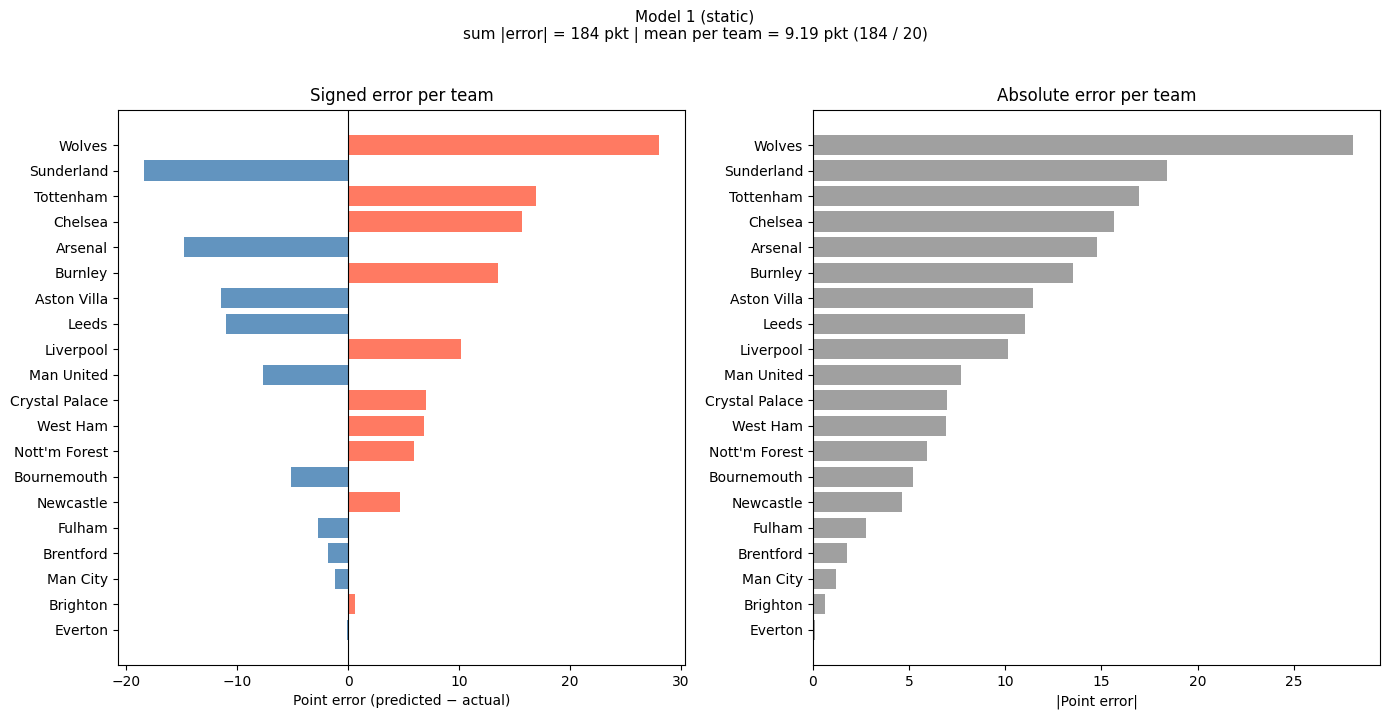

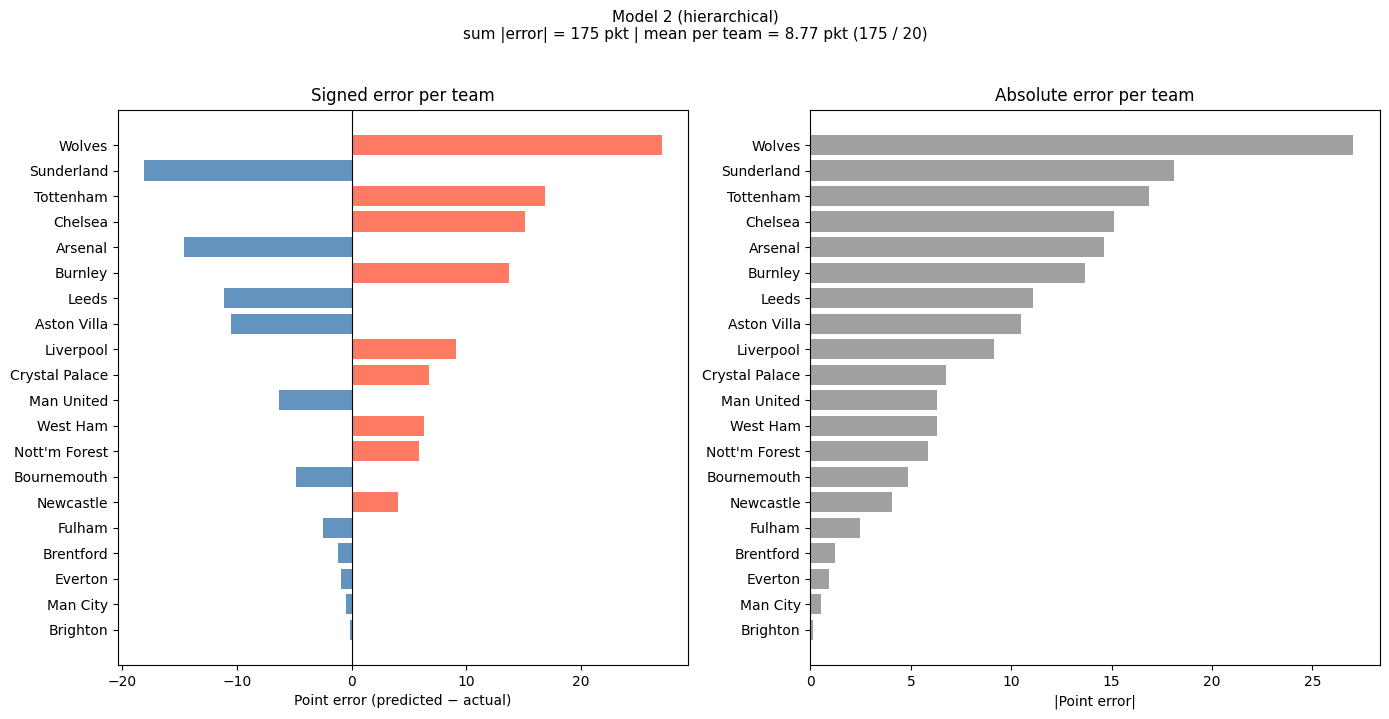

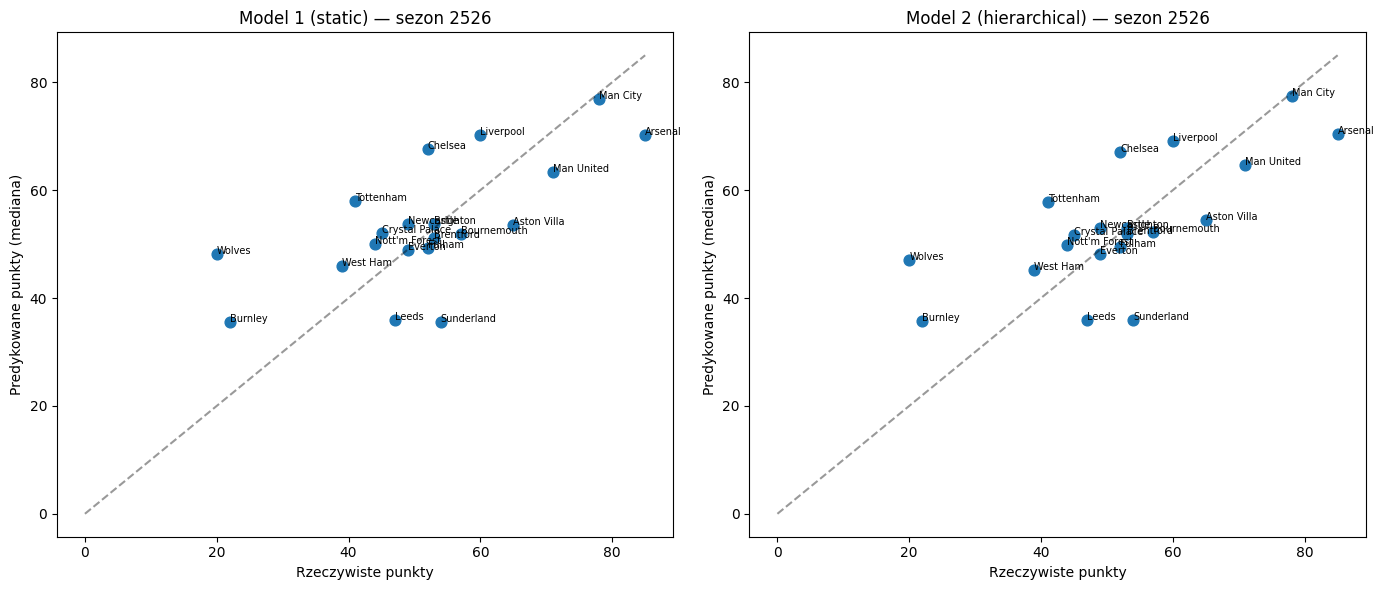

In [4]:
plot_forecast_team_errors(cmp_static, season=TEST, title="Model 1 (static)")
plt.show()
plot_forecast_team_errors(cmp_hier, season=TEST, title="Model 2 (hierarchical)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cmp, title in [
    (axes[0], cmp_static, "Model 1 (static)"),
    (axes[1], cmp_hier, "Model 2 (hierarchical)"),
]:
    ax.scatter(cmp["pts_actual"], cmp["pts_median"], s=60)
    for _, r in cmp.iterrows():
        ax.annotate(r["team"], (r["pts_actual"], r["pts_median"]), fontsize=7)
    mx = max(cmp["pts_actual"].max(), cmp["pts_median"].max())
    ax.plot([0, mx], [0, mx], "k--", alpha=0.4)
    ax.set_xlabel("Rzeczywiste punkty")
    ax.set_ylabel("Predykowane punkty (mediana)")
    ax.set_title(f"{title} — sezon {TEST}")
plt.tight_layout()
plt.show()
